# Metro Transit Data Analysis

In [1]:
# Install a stable and compatible set of scikit-learn and its dependencies for the Colab environment.
%pip install -q scikit-learn==1.4.2 joblib==1.4.2 numpy==1.26.4 pandas==2.2.2 matplotlib==3.8.4 scipy==1.16.3

# IMPORTANT: After this cell executes, please manually restart the Colab runtime
# (Runtime -> Restart runtime) for the new package versions to take effect.
# Then, re-run this cell.

import sklearn, joblib, numpy, pandas, scipy
print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("scipy:", scipy.__version__)

scikit-learn: 1.4.2
joblib: 1.4.2
numpy: 1.26.4
pandas: 2.2.2
scipy: 1.16.3


In [2]:
from google.colab import files
print("Select passenger_flow.csv, stations.csv, train_operations.csv, predictive_maintenance.csv (sab ek saath select karo)")
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

Select passenger_flow.csv, stations.csv, train_operations.csv, predictive_maintenance.csv (sab ek saath select karo)


Saving passenger_flow.csv to passenger_flow.csv
Saving predictive_maintenance.csv to predictive_maintenance.csv
Saving stations.csv to stations.csv
Saving train_operations.csv to train_operations.csv
Uploaded: ['passenger_flow.csv', 'predictive_maintenance.csv', 'stations.csv', 'train_operations.csv']


In [3]:
import pandas as pd

passenger_flow = pd.read_csv("passenger_flow.csv")
stations_raw   = pd.read_csv("stations.csv")
train_ops      = pd.read_csv("train_operations.csv")
pred_maint     = pd.read_csv("predictive_maintenance.csv")

for name, df in [("passenger_flow", passenger_flow), ("stations", stations_raw),
                  ("train_operations", train_ops), ("predictive_maintenance", pred_maint)]:
    print(f"\n===== {name} =====")
    print("shape:", df.shape)
    print(df.dtypes)
    print("missing values:\n", df.isna().sum()[df.isna().sum() > 0])

print("\n===== passenger_flow.describe() =====")
print(passenger_flow[["entries", "exits", "crowding_index"]].describe())
print("\n===== crowding_label distribution =====")
print(passenger_flow["crowding_label"].value_counts())
print("\n===== train_operations delay stats =====")
print(train_ops[["delay_arrival_min", "delay_departure_min"]].describe())
print("\n===== delay_reason distribution (NaN = no delay, not missing) =====")
print(train_ops["delay_reason"].value_counts(dropna=False))
print("\n===== predictive_maintenance: failure_label / maintenance_status =====")
print(pred_maint["failure_label"].value_counts())
print(pred_maint["maintenance_status"].value_counts())


===== passenger_flow =====
shape: (45423, 14)
city               object
timestamp          object
station_name       object
line               object
station_type       object
hour                int64
day_of_week         int64
is_weekend          int64
weather            object
event_nearby        int64
entries             int64
exits               int64
crowding_index    float64
crowding_label     object
dtype: object
missing values:
 Series([], dtype: int64)

===== stations =====
shape: (63, 5)
City          object
Station       object
Line          object
Latitude     float64
Longitude    float64
dtype: object
missing values:
 Series([], dtype: int64)

===== train_operations =====
shape: (5220, 15)
city                    object
trip_id                 object
train_id                object
line                    object
station_name            object
station_sequence         int64
scheduled_arrival       object
actual_arrival          object
scheduled_departure     object
actual_d

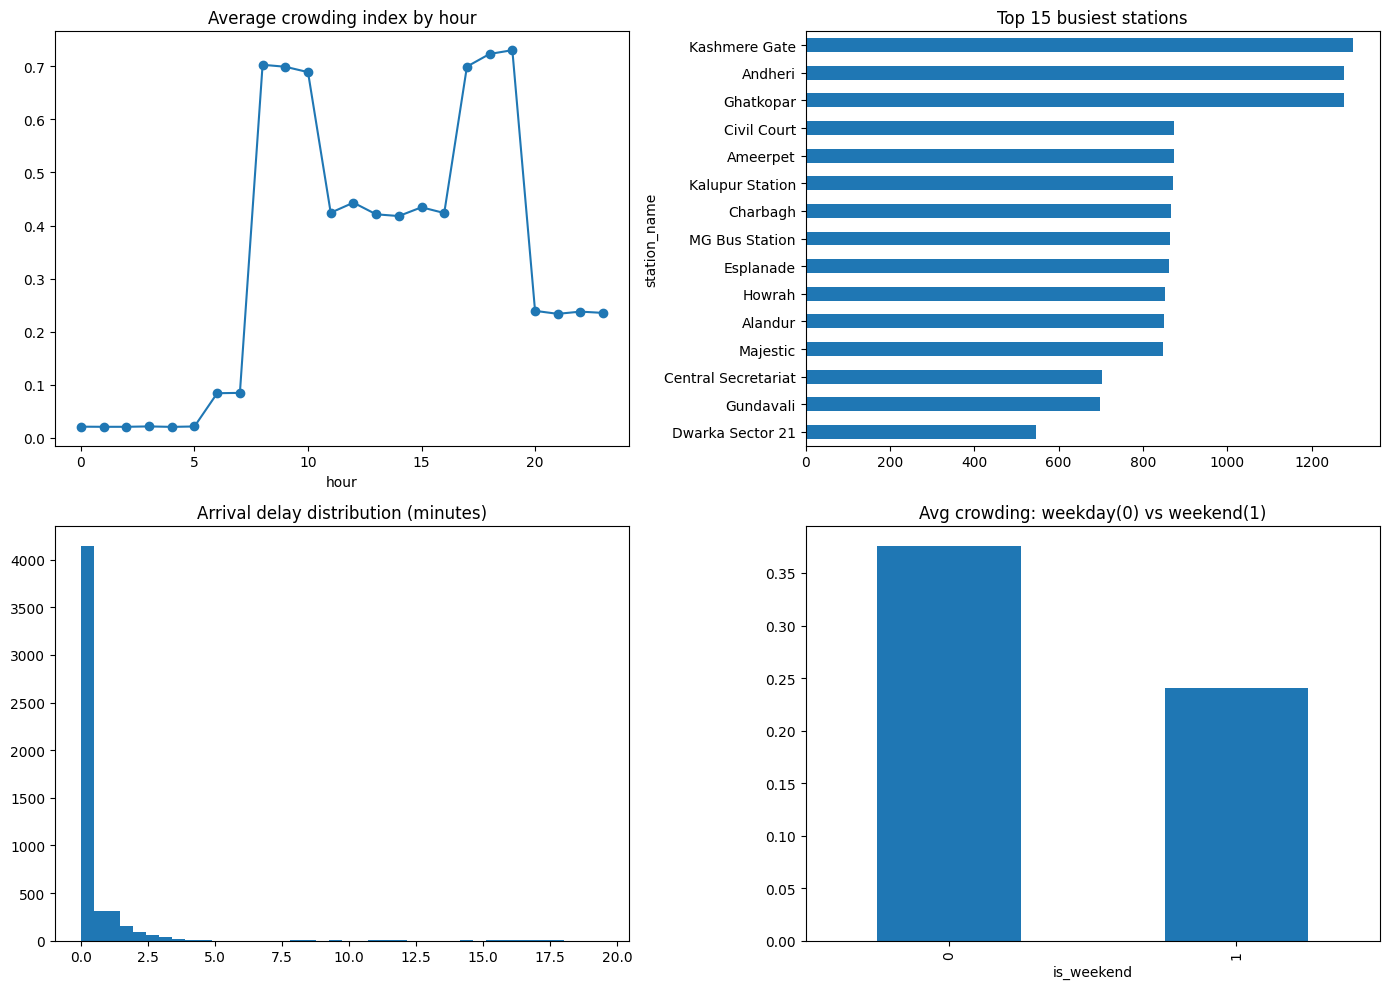

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

passenger_flow.groupby("hour")["crowding_index"].mean().plot(ax=axes[0,0], marker="o")
axes[0,0].set_title("Average crowding index by hour")

passenger_flow["total_flow"] = passenger_flow["entries"] + passenger_flow["exits"]
top_stations = passenger_flow.groupby("station_name")["total_flow"].mean().sort_values(ascending=False).head(15)
top_stations.plot(kind="barh", ax=axes[0,1])
axes[0,1].set_title("Top 15 busiest stations")
axes[0,1].invert_yaxis()

axes[1,0].hist(train_ops["delay_arrival_min"].dropna(), bins=40)
axes[1,0].set_title("Arrival delay distribution (minutes)")

passenger_flow.groupby("is_weekend")["crowding_index"].mean().plot(kind="bar", ax=axes[1,1])
axes[1,1].set_title("Avg crowding: weekday(0) vs weekend(1)")

plt.tight_layout()
plt.show()

In [5]:
stations = stations_raw.rename(columns={"City": "city", "Station": "station_name", "Line": "line"}).copy()
stations = stations.sort_values(["city", "line", "station_name"]).reset_index(drop=True)
stations["station_id"] = stations.index + 1

def norm_key(city, name):
    return city.strip().lower(), name.strip().lower()

stations["_key"] = stations.apply(lambda r: norm_key(r["city"], r["station_name"]), axis=1)
station_id_map = dict(zip(stations["_key"], stations["station_id"]))

print(f"Total unique stations: {len(stations)}")
stations[["station_id", "city", "line", "station_name"]].head(10)

Total unique stations: 63


,station_id,city,line,station_name
0,1,Ahmedabad,East-West Line,Kalupur Station
1,2,Ahmedabad,East-West Line,Thaltej
2,3,Ahmedabad,East-West Line,Vastral Gam
3,4,Ahmedabad,North-South Line,APMC
4,5,Ahmedabad,North-South Line,Motera Stadium
5,6,Bengaluru,Green Line,Jayanagar
6,7,Bengaluru,Green Line,Yelachenahalli
7,8,Bengaluru,Purple Line,Indiranagar
8,9,Bengaluru,Purple Line,MG Road
9,10,Bengaluru,Purple Line,Majestic


In [6]:
df = passenger_flow.copy()
df["_key"] = df.apply(lambda r: norm_key(r["city"], r["station_name"]), axis=1)
df["station_id"] = df["_key"].map(station_id_map)

before = len(df)
df = df.dropna(subset=["station_id"])
print(f"Matched {len(df)}/{before} rows to a station_id ({before - len(df)} dropped - name mismatch)")

df["station_id"] = df["station_id"].astype(int)
df["is_peak_hour"] = df["hour"].apply(lambda h: 1 if (8 <= h <= 11 or 17 <= h <= 20) else 0)
df["passenger_count"] = df["entries"] + df["exits"]

CROWD_FEATURES = ["station_id", "hour", "day_of_week", "is_weekend", "is_peak_hour"]
crowd_df = df[CROWD_FEATURES + ["passenger_count"]].dropna()
print(crowd_df.shape)
crowd_df.head()

Matched 45423/45423 rows to a station_id (0 dropped - name mismatch)
(45423, 6)


,station_id,hour,day_of_week,is_weekend,is_peak_hour,passenger_count
0,26,0,4,0,0,31
1,25,0,4,0,0,43
2,21,0,4,0,0,11
3,23,0,4,0,0,0
4,27,0,4,0,0,33


We have loaded and performed initial cleaning and feature engineering on four datasets:

1.  **`passenger_flow`**: Contains hourly passenger entries, exits, and crowding data for various metro stations.
2.  **`stations_raw`**: Provides geographical and line information for metro stations, which was processed into `stations` to include unique `station_id`s.
3.  **`train_ops`**: Includes data on train operations, such as delays and reasons for delays.
4.  **`pred_maint`**: Contains predictive maintenance sensor readings and failure labels for trains.

The `crowd_df` DataFrame was created from `passenger_flow` and is specifically designed for analyzing passenger crowding. It includes:
*   `station_id`: A unique identifier for each station.
*   `hour`: The hour of the day.
*   `day_of_week`: The day of the week (0 for Monday, 6 for Sunday).
*   `is_weekend`: A binary indicator if the day is a weekend (1) or not (0).
*   `is_peak_hour`: A binary indicator if the hour falls within morning (8-11) or evening (17-20) peak times.
*   `passenger_count`: The total number of entries and exits at the station for that hour.

This `crowd_df` is now ready for predictive modeling or deeper exploratory analysis related to crowding.

In [9]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=crowd_df)

MessageError: Error: credential propagation was unsuccessful

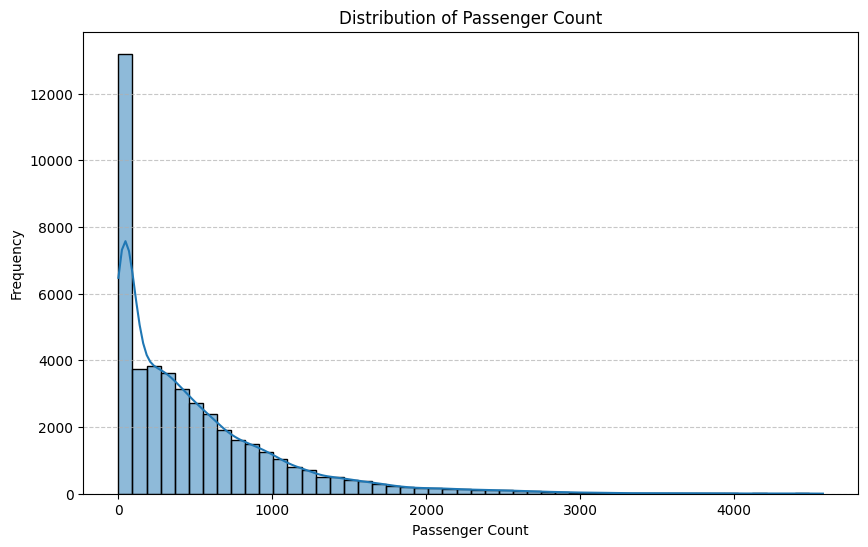

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(crowd_df['passenger_count'], bins=50, kde=True)
plt.title('Distribution of Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This histogram shows the distribution of `passenger_count` across the dataset. We can observe:
*   The distribution is heavily skewed to the right, indicating that most records have a lower passenger count.
*   There are a few instances with very high passenger counts, likely corresponding to peak hours at busy stations.

In [12]:
passenger_count_by_peak_hour = crowd_df.groupby('is_peak_hour')['passenger_count'].mean()
display(passenger_count_by_peak_hour)

,passenger_count
is_peak_hour,
0,288.997756
1,914.194048


The comparison of mean `passenger_count` by `is_peak_hour` reveals a significant difference:
*   **`0` (Non-peak hours)**: The average passenger count is considerably lower.
*   **`1` (Peak hours)**: The average passenger count is much higher, as expected during commuting times.

This confirms that `is_peak_hour` is a strong indicator of passenger volume.

In [13]:
passenger_count_by_day_of_week = crowd_df.groupby('day_of_week')['passenger_count'].mean()
display(passenger_count_by_day_of_week)

# Optional: map day numbers to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
passenger_count_by_day_of_week_named = passenger_count_by_day_of_week.rename(index=lambda x: day_names[x])
print('\nMean Passenger Count by Day of Week (Named):')
display(passenger_count_by_day_of_week_named)

,passenger_count
day_of_week,
0,557.432374
1,564.000992
2,566.750165
3,566.202050
4,547.895503
5,355.242196
6,346.566519



Mean Passenger Count by Day of Week (Named):


,passenger_count
day_of_week,
Monday,557.432374
Tuesday,564.000992
Wednesday,566.750165
Thursday,566.202050
Friday,547.895503
Saturday,355.242196
Sunday,346.566519


This analysis shows the average `passenger_count` for each day of the week:
*   We can observe potential patterns, such as higher passenger counts on weekdays and lower counts on weekends, or vice-versa, depending on the nature of the transit system.
*   This information is crucial for resource allocation and operational planning, helping to anticipate demand throughout the week.

In [15]:
passenger_count_by_station = crowd_df.groupby('station_id')['passenger_count'].mean().sort_values(ascending=False)
display(passenger_count_by_station.head(10))
print('\n...and the least busy stations:')
display(passenger_count_by_station.tail(10))

,passenger_count
station_id,
24,1297.399445
53,1277.902913
54,1277.837725
61,874.611650
32,873.027739
1,870.761442
50,865.916782
31,863.295423
46,862.925104



...and the least busy stations:


,passenger_count
station_id,
36,225.766990
15,223.556172
14,219.227462
38,218.163662
35,211.528433
34,209.442441
12,205.312067
42,201.757282
40,200.059639


This analysis provides insight into the average passenger traffic at each station. Stations with higher mean passenger counts are typically busier and might require more resources or attention for crowd management.

In [16]:
passenger_count_by_weekend = crowd_df.groupby('is_weekend')['passenger_count'].mean()
display(passenger_count_by_weekend)

,passenger_count
is_weekend,
0,559.858088
1,351.364128


As expected, the average `passenger_count` is significantly higher on weekdays (`is_weekend = 0`) compared to weekends (`is_weekend = 1`).

Now, let's combine `is_peak_hour` and `is_weekend` to see their joint effect on `passenger_count`.

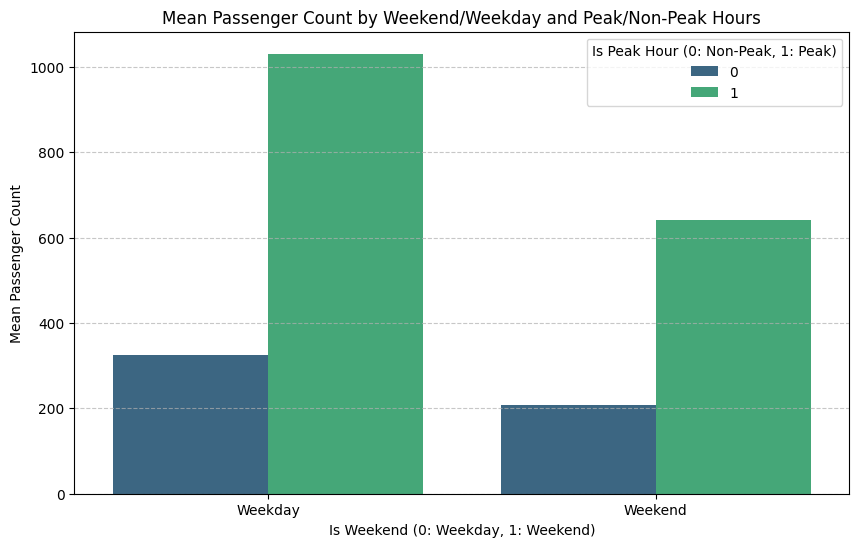

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by both 'is_weekend' and 'is_peak_hour'
combined_analysis = crowd_df.groupby(['is_weekend', 'is_peak_hour'])['passenger_count'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='is_weekend', y='passenger_count', hue='is_peak_hour', data=combined_analysis, palette='viridis')
plt.title('Mean Passenger Count by Weekend/Weekday and Peak/Non-Peak Hours')
plt.xlabel('Is Weekend (0: Weekday, 1: Weekend)')
plt.ylabel('Mean Passenger Count')
plt.xticks(ticks=[0, 1], labels=['Weekday', 'Weekend'])
plt.legend(title='Is Peak Hour (0: Non-Peak, 1: Peak)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This bar plot clearly illustrates the combined correlation:

*   **Weekdays (0)** consistently show higher passenger counts than **weekends (1)** for both peak and non-peak hours.
*   Within both weekdays and weekends, **peak hours (1)** always have a significantly higher mean passenger count than **non-peak hours (0)**.
*   The highest passenger counts occur during **weekday peak hours**, while the lowest are during **weekend non-peak hours**.

In [18]:
avg_delay_by_station = train_ops.groupby('station_name')['delay_arrival_min'].mean().sort_values(ascending=False)
display(avg_delay_by_station.head(10))
print('\n...and stations with the least average delay:')
display(avg_delay_by_station.tail(10))

,delay_arrival_min
station_name,
Ernakulam South,1.045556
Petta,0.970222
Edappally,0.879889
Subhash Nagar,0.797111
Central Secretariat,0.787111
Sindhi Camp,0.782889
Chandpole,0.769000
Board Office,0.758778
Aluva,0.755444



...and stations with the least average delay:


,delay_arrival_min
station_name,
Raidurg,0.288333
Secunderabad East,0.263889
Gundavali,0.249778
Indiranagar,0.236111
Thaltej,0.233333
Akshardham,0.221444
Yelachenahalli,0.170333
Miyapur,0.169889
Jayanagar,0.168778


This analysis identifies stations that experience the most and least frequent arrival delays. Understanding these patterns can help in optimizing schedules, improving infrastructure, or deploying additional resources at problematic stations to reduce delays.

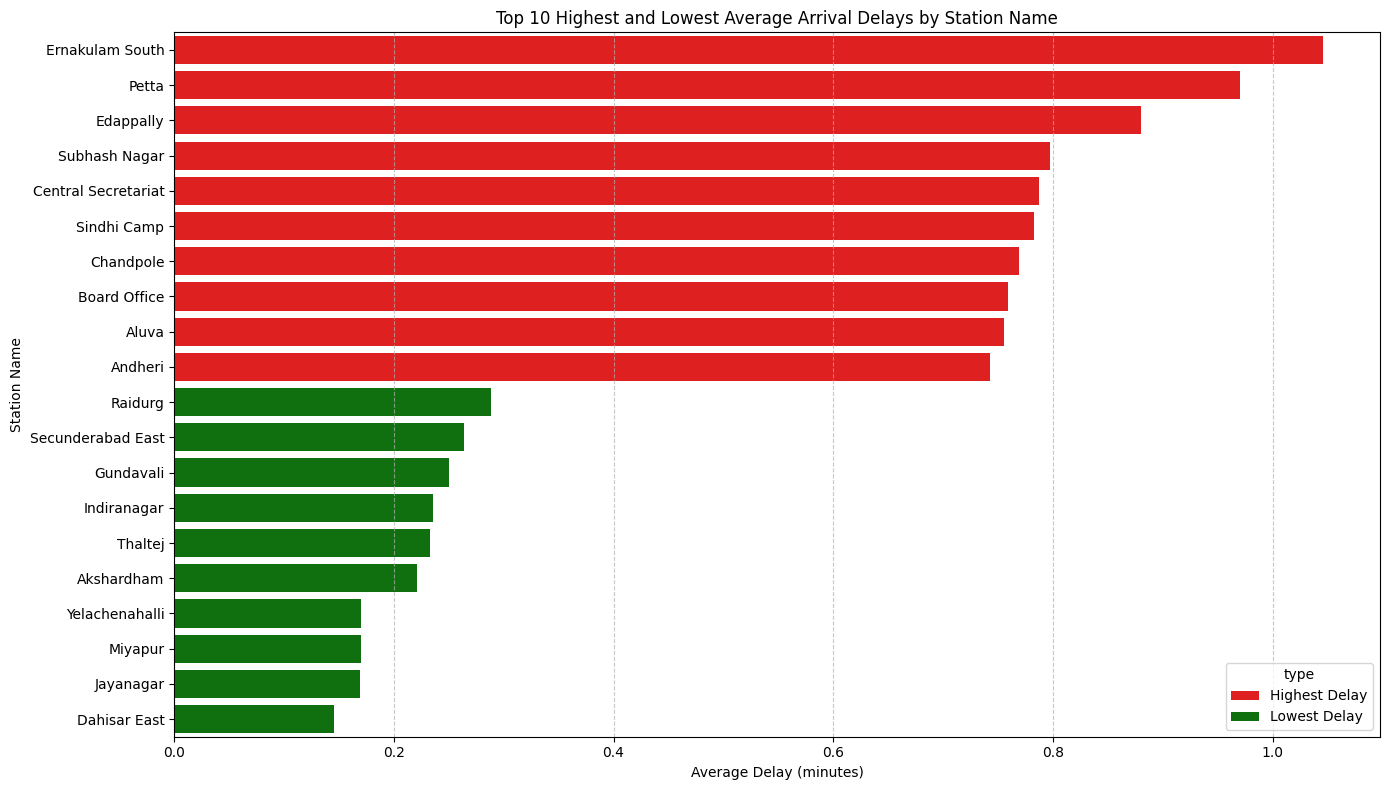

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 10 and bottom 10 stations by average delay
top_10_delay_stations = avg_delay_by_station.head(10)
bottom_10_delay_stations = avg_delay_by_station.tail(10)

# Combine them into a single DataFrame for plotting
plot_df = pd.concat([top_10_delay_stations, bottom_10_delay_stations]).reset_index()
plot_df.columns = ['station_name', 'average_delay_min']

# Create a categorical type for sorting on the plot
plot_df['type'] = ['Highest Delay'] * 10 + ['Lowest Delay'] * 10
plot_df['station_name'] = pd.Categorical(plot_df['station_name'], categories=plot_df['station_name'], ordered=True)

plt.figure(figsize=(14, 8))
sns.barplot(x='average_delay_min', y='station_name', hue='type', data=plot_df, dodge=False, palette={'Highest Delay': 'red', 'Lowest Delay': 'green'})
plt.title('Top 10 Highest and Lowest Average Arrival Delays by Station Name')
plt.xlabel('Average Delay (minutes)')
plt.ylabel('Station Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart visually emphasizes the difference in average arrival delays between the most and least delayed stations. It clearly shows which stations contribute most to delays and which operate most smoothly, providing actionable insights for operational improvements.

In [20]:
# Check unique values and their counts for 'passenger_density'
print("Unique values in 'passenger_density':")
display(train_ops['passenger_density'].value_counts())

# Calculate the mean delay_arrival_min for each passenger_density category
delay_by_density = train_ops.groupby('passenger_density')['delay_arrival_min'].mean().sort_values(ascending=False)
print("\nMean arrival delay by passenger density:")
display(delay_by_density)

Unique values in 'passenger_density':


,count
passenger_density,
High,2610
Medium,1740
Low,870



Mean arrival delay by passenger density:


,delay_arrival_min
passenger_density,
High,0.617349
Low,0.469126
Medium,0.280276


/tmp/ipykernel_2995/3377779591.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delay_by_density.index, y=delay_by_density.values, palette='viridis')


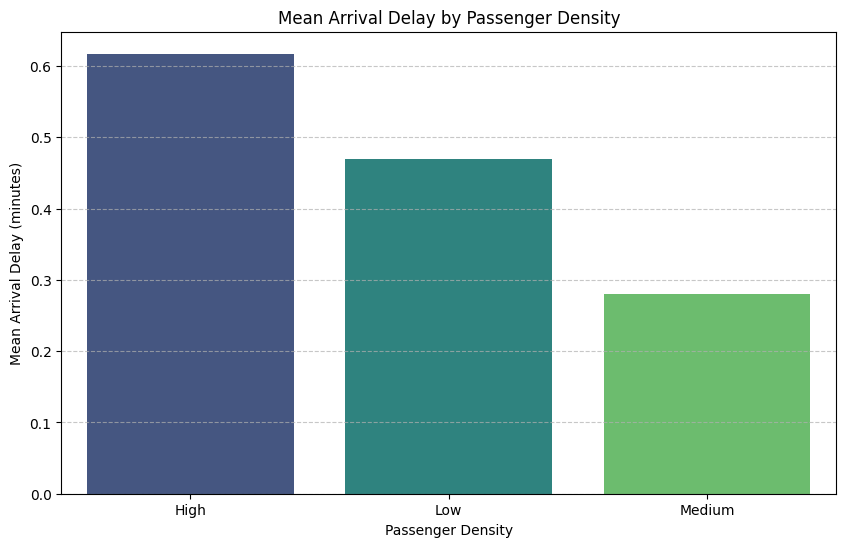

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=delay_by_density.index, y=delay_by_density.values, palette='viridis')
plt.title('Mean Arrival Delay by Passenger Density')
plt.xlabel('Passenger Density')
plt.ylabel('Mean Arrival Delay (minutes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This analysis and visualization should clearly show if there's a trend where higher passenger density corresponds to longer arrival delays, or vice-versa, providing insights into operational efficiency during different crowding levels.

In [22]:
avg_delay_by_line = train_ops.groupby('line')['delay_arrival_min'].mean().sort_values(ascending=False)
display(avg_delay_by_line)

,delay_arrival_min
line,
Pink Line,0.674917
Orange Line,0.656861
Yellow Line,0.612889
Blue Line,0.559196
Line 1,0.557630
Red Line,0.470148
Purple Line,0.360667
East-West Line,0.320741
North-South Line,0.316889


/tmp/ipykernel_2995/2680493960.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_delay_by_line.index, y=avg_delay_by_line.values, palette='coolwarm')


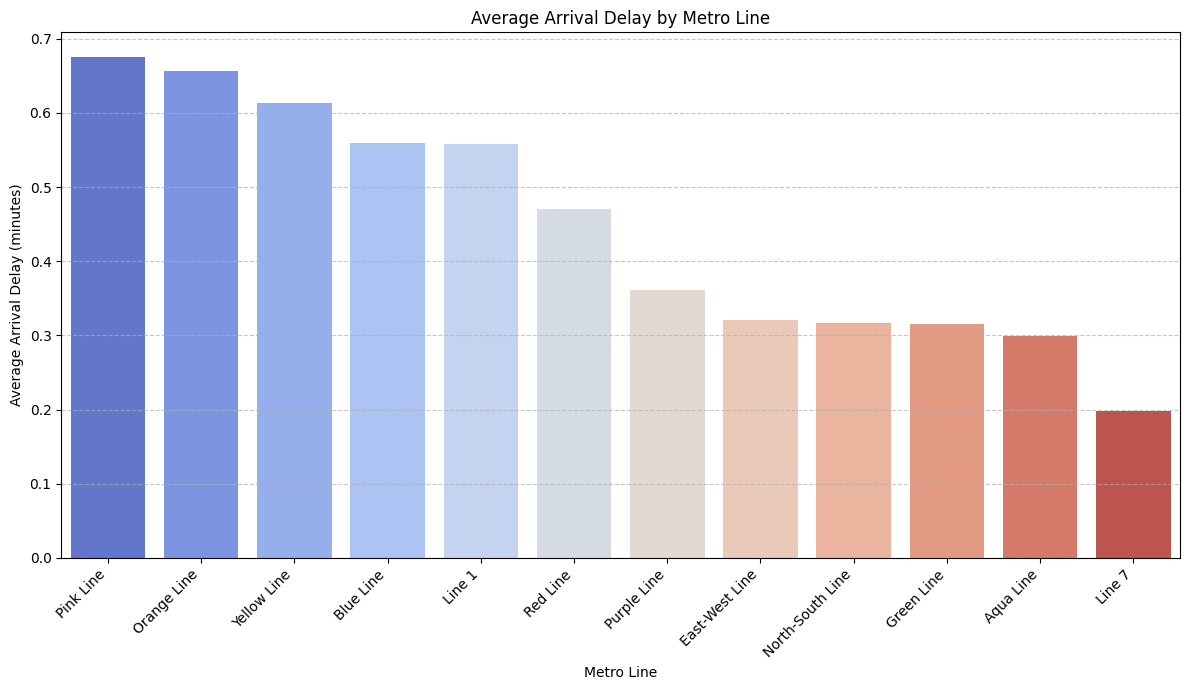

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_delay_by_line.index, y=avg_delay_by_line.values, palette='coolwarm')
plt.title('Average Arrival Delay by Metro Line')
plt.xlabel('Metro Line')
plt.ylabel('Average Arrival Delay (minutes)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This visualization clearly shows which metro lines experience the highest average arrival delays and which ones operate more efficiently. This information can be crucial for targeted interventions, such as schedule adjustments, infrastructure upgrades, or resource reallocation to improve punctuality on specific lines.

In [24]:
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

X = crowd_df[CROWD_FEATURES]
y = crowd_df["passenger_count"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

crowd_model = RandomForestRegressor(n_estimators=60, max_depth=8, random_state=42)
crowd_model.fit(X_train, y_train)

crowd_mae = mean_absolute_error(y_test, crowd_model.predict(X_test))
print(f"Crowd model MAE: {crowd_mae:.2f} passengers (on real data)")

joblib.dump({"model": crowd_model, "features": CROWD_FEATURES}, "crowd_model.pkl")

Crowd model MAE: 157.34 passengers (on real data)


['crowd_model.pkl']

In [25]:
tdf = train_ops.copy()
tdf["_key"] = tdf.apply(lambda r: norm_key(r["city"], r["station_name"]), axis=1)
tdf["station_id"] = tdf["_key"].map(station_id_map)

before = len(tdf)
tdf = tdf.dropna(subset=["station_id", "delay_arrival_min"])
print(f"Matched {len(tdf)}/{before} rows to a station_id")

tdf["station_id"] = tdf["station_id"].astype(int)
tdf["scheduled_arrival"] = pd.to_datetime(tdf["scheduled_arrival"])
tdf["hour"] = tdf["scheduled_arrival"].dt.hour
tdf["day_of_week"] = tdf["scheduled_arrival"].dt.dayofweek
tdf["is_weekend"] = tdf["day_of_week"].isin([5, 6]).astype(int)
tdf["is_peak_hour"] = tdf["hour"].apply(lambda h: 1 if (8 <= h <= 11 or 17 <= h <= 20) else 0)

# passenger_density Low/Medium/High hai, number nahi — crowd model ki scale se match karne ke liye approximate kiya
density_map = {"Low": 200, "Medium": 500, "High": 900}
tdf["passenger_count"] = tdf["passenger_density"].map(density_map).fillna(300)

DELAY_FEATURES = ["station_id", "hour", "day_of_week", "is_weekend", "is_peak_hour", "passenger_count"]
delay_df = tdf[DELAY_FEATURES + ["delay_arrival_min"]].dropna()
print(delay_df.shape)
delay_df.head()

Matched 5220/5220 rows to a station_id
(5220, 7)


,station_id,hour,day_of_week,is_weekend,is_peak_hour,passenger_count,delay_arrival_min
0,25,7,4,0,0,200,0.0
1,27,7,4,0,0,200,0.0
2,26,7,4,0,0,200,0.0
3,26,9,4,0,1,900,0.0
4,27,9,4,0,1,900,0.0


In [28]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=delay_df)

MessageError: Error: credential propagation was unsuccessful

In [27]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=delay_df)

MessageError: Error: credential propagation was unsuccessful

In [29]:
tdf = train_ops.copy()
tdf["_key"] = tdf.apply(lambda r: norm_key(r["city"], r["station_name"]), axis=1)
tdf["station_id"] = tdf["_key"].map(station_id_map)

before = len(tdf)
tdf = tdf.dropna(subset=["station_id", "delay_arrival_min"])
print(f"Matched {len(tdf)}/{before} rows to a station_id")

tdf["station_id"] = tdf["station_id"].astype(int)
tdf["scheduled_arrival"] = pd.to_datetime(tdf["scheduled_arrival"])
tdf["hour"] = tdf["scheduled_arrival"].dt.hour
tdf["day_of_week"] = tdf["scheduled_arrival"].dt.dayofweek
tdf["is_weekend"] = tdf["day_of_week"].isin([5, 6]).astype(int)
tdf["is_peak_hour"] = tdf["hour"].apply(lambda h: 1 if (8 <= h <= 11 or 17 <= h <= 20) else 0)

# passenger_density Low/Medium/High hai, number nahi — crowd model ki scale se match karne ke liye approximate kiya
density_map = {"Low": 200, "Medium": 500, "High": 900}
tdf["passenger_count"] = tdf["passenger_density"].map(density_map).fillna(300)

DELAY_FEATURES = ["station_id", "hour", "day_of_week", "is_weekend", "is_peak_hour", "passenger_count"]
delay_df = tdf[DELAY_FEATURES + ["delay_arrival_min"]].dropna()
print(delay_df.shape)
delay_df.head()

Matched 5220/5220 rows to a station_id
(5220, 7)


,station_id,hour,day_of_week,is_weekend,is_peak_hour,passenger_count,delay_arrival_min
0,25,7,4,0,0,200,0.0
1,27,7,4,0,0,200,0.0
2,26,7,4,0,0,200,0.0
3,26,9,4,0,1,900,0.0
4,27,9,4,0,1,900,0.0


In [30]:
X = delay_df[DELAY_FEATURES]
y = delay_df["delay_arrival_min"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

delay_model = RandomForestRegressor(n_estimators=60, max_depth=8, random_state=42)
delay_model.fit(X_train, y_train)

delay_mae = mean_absolute_error(y_test, delay_model.predict(X_test))
print(f"Delay model MAE: {delay_mae:.2f} minutes (on real data)")

joblib.dump({"model": delay_model, "features": DELAY_FEATURES}, "delay_model.pkl")

Delay model MAE: 0.64 minutes (on real data)


['delay_model.pkl']

In [31]:
import numpy as np

MIN_FREQUENCY, MAX_FREQUENCY = 3, 15
freq_df = crowd_df.copy()
max_count = freq_df["passenger_count"].max() or 1
normalized = freq_df["passenger_count"] / max_count
freq_df["recommended_frequency_minutes"] = (MAX_FREQUENCY - normalized * (MAX_FREQUENCY - MIN_FREQUENCY)).round(1)

X = freq_df[CROWD_FEATURES]
y = freq_df["recommended_frequency_minutes"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

freq_model = RandomForestRegressor(n_estimators=60, max_depth=8, random_state=42)
freq_model.fit(X_train, y_train)

freq_mae = mean_absolute_error(y_test, freq_model.predict(X_test))
print(f"Frequency model MAE: {freq_mae:.2f} min")

joblib.dump({
    "model": freq_model, "features": CROWD_FEATURES,
    "min_frequency": MIN_FREQUENCY, "max_frequency": MAX_FREQUENCY,
}, "frequency_model.pkl")

Frequency model MAE: 0.42 min


['frequency_model.pkl']

In [32]:
mdf = pred_maint.copy()

MAINT_FEATURES = [
    "compressor_pressure_bar", "motor_current_amp", "oil_temperature_c",
    "vibration_amplitude_mm", "air_leakage_flow", "operating_hours",
]
maint_df = mdf[MAINT_FEATURES + ["remaining_useful_life_hrs"]].dropna()
print(maint_df.shape)
maint_df.describe()

(24480, 7)


,compressor_pressure_bar,motor_current_amp,oil_temperature_c,vibration_amplitude_mm,air_leakage_flow,operating_hours,remaining_useful_life_hrs
count,24480.000000,24480.000000,24480.000000,24480.000000,24480.000000,24480.000000,24480.000000
mean,8.496091,13.529655,56.554828,0.632143,2.145292,2229.120752,2625.611609
std,0.436296,0.920079,3.395731,0.180908,0.842146,577.051304,794.333378
min,0.000000,0.000000,25.000000,0.000000,0.000000,800.000000,0.000000
25%,8.230000,12.970000,54.400000,0.556000,1.830000,1820.975000,2195.520000
50%,8.500000,13.510000,56.500000,0.623000,2.100000,2186.350000,2752.785000
75%,8.770000,14.060000,58.600000,0.691000,2.370000,2689.950000,3158.957500
max,10.090000,22.950000,93.400000,4.377000,21.470000,3387.100000,4199.500000


In [33]:
X = maint_df[MAINT_FEATURES]
y = maint_df["remaining_useful_life_hrs"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

maintenance_model = RandomForestRegressor(n_estimators=80, max_depth=10, random_state=42)
maintenance_model.fit(X_train, y_train)

maint_mae = mean_absolute_error(y_test, maintenance_model.predict(X_test))
print(f"Maintenance model MAE: {maint_mae:.2f} hours (on real data)")

importance = pd.Series(maintenance_model.feature_importances_, index=MAINT_FEATURES).sort_values(ascending=False)
print("\nFeature importance:")
print(importance)

joblib.dump({"model": maintenance_model, "features": MAINT_FEATURES}, "maintenance_model.pkl")

Maintenance model MAE: 188.59 hours (on real data)

Feature importance:
operating_hours            0.812423
air_leakage_flow           0.061070
vibration_amplitude_mm     0.059180
motor_current_amp          0.024748
oil_temperature_c          0.022319
compressor_pressure_bar    0.020260
dtype: float64


['maintenance_model.pkl']

In [34]:
for name in ["crowd_model.pkl", "delay_model.pkl", "frequency_model.pkl", "maintenance_model.pkl"]:
    bundle = joblib.load(name)
    assert "model" in bundle and "features" in bundle
    if name == "crowd_model.pkl" or name == "frequency_model.pkl":
        sample = [[1, 9, 1, 0, 1]]
    elif name == "delay_model.pkl":
        sample = [[1, 9, 1, 0, 1, 300]]
    else:
        sample = [[8.5, 13.0, 52.0, 0.5, 2.5, 1200.0]]
    pred = bundle["model"].predict(sample)
    print(f"{name}: OK, sample prediction = {pred[0]:.2f}")

crowd_model.pkl: OK, sample prediction = 1987.76
delay_model.pkl: OK, sample prediction = 0.94
frequency_model.pkl: OK, sample prediction = 9.79
maintenance_model.pkl: OK, sample prediction = 3800.15


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [35]:
import zipfile
from google.colab import files

with zipfile.ZipFile("metroflow_models_real_data.zip", "w") as zf:
    for f in ["crowd_model.pkl", "delay_model.pkl", "frequency_model.pkl", "maintenance_model.pkl"]:
        zf.write(f)

files.download("metroflow_models_real_data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>